# 03 — Insights & SQL Analysis
**London Crime Analysis (2020–2024)**

We load the clean data into SQLite and answer business-style questions with SQL.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BLUE = '#1A3A5C'

# Load clean data
df = pd.read_csv('../data/processed/london_crime_clean.csv', parse_dates=['month'])
print(f'Loaded {len(df):,} rows')

# Push into in-memory SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('crime', conn, index=False, if_exists='replace')
print('SQLite table "crime" ready ✅')

Loaded 3,399,506 rows
SQLite table "crime" ready ✅


## SQL Helper

In [2]:
def query(sql):
    return pd.read_sql_query(sql, conn)

## Q1 — Total incidents per year

In [3]:
query("""
SELECT year,
       COUNT(*) AS total_incidents
FROM crime
GROUP BY year
ORDER BY year
""")

,year,total_incidents
0,2023,856305
1,2024,1138656
2,2025,1140416
3,2026,264129


## Q2 — Top 10 boroughs by crime (2024)

In [4]:
query("""
SELECT borough,
       COUNT(*) AS incidents_2024
FROM crime
WHERE year = 2024
GROUP BY borough
ORDER BY incidents_2024 DESC
LIMIT 10
""")

,borough,incidents_2024
0,Westminster,103099
1,Camden,50903
2,Newham,49438
3,Southwark,47955
4,Lambeth,47633
5,Tower,46331
6,Croydon,43495
7,Brent,42439
8,Ealing,41831
9,Hackney,40475


## Q3 — Year-over-year % change per borough

In [5]:
query("""
WITH yr AS (
    SELECT borough, year, COUNT(*) AS cnt
    FROM crime
    GROUP BY borough, year
)
SELECT
    a.borough,
    a.cnt  AS crimes_2023,
    b.cnt  AS crimes_2025,
    ROUND((CAST(b.cnt AS FLOAT) - a.cnt) / a.cnt * 100, 1) AS change_pct
FROM yr a
JOIN yr b ON a.borough = b.borough AND a.year = 2020 AND b.year = 2024
ORDER BY change_pct DESC
LIMIT 15
""")

,borough,crimes_2023,crimes_2025,change_pct


## Q4 — Most dangerous crime type per borough

In [6]:
query("""
WITH ranked AS (
    SELECT borough, crime_type, COUNT(*) AS cnt,
           RANK() OVER (PARTITION BY borough ORDER BY COUNT(*) DESC) AS rnk
    FROM crime
    GROUP BY borough, crime_type
)
SELECT borough, crime_type, cnt AS total_incidents
FROM ranked
WHERE rnk = 1
ORDER BY cnt DESC
LIMIT 15
""")

,borough,crime_type,total_incidents
0,Westminster,Theft From The Person,79771
1,Croydon,Violence And Sexual Offences,36803
2,Tower,Anti-Social Behaviour,33767
3,Newham,Violence And Sexual Offences,33672
4,Ealing,Violence And Sexual Offences,32431
5,Lambeth,Violence And Sexual Offences,31428
6,Brent,Violence And Sexual Offences,30841
7,Lewisham,Violence And Sexual Offences,30483
8,Greenwich,Violence And Sexual Offences,29261
9,Camden,Anti-Social Behaviour,29026


## Q5 — Seasonal pattern: which month has most crime?

In [7]:
query("""
SELECT month_name,
       month_num,
       COUNT(*) AS total_incidents
FROM crime
GROUP BY month_name, month_num
ORDER BY month_num
""")

,month_name,month_num,total_incidents
0,January,1,264383
1,February,2,259071
2,March,3,277963
3,April,4,268865
4,May,5,291882
5,June,6,301776
6,July,7,305505
7,August,8,290173
8,September,9,282574
9,October,10,294375


## Q6 — COVID impact: crime drop in lockdown months (Mar–Jun 2020)

In [8]:
query("""
SELECT
    CASE
        WHEN year = 2023 AND month_num BETWEEN 6 AND 9 THEN 'Summer 2023'
        WHEN year = 2024 AND month_num BETWEEN 6 AND 9 THEN 'Summer 2024'
        WHEN year = 2025 AND month_num BETWEEN 6 AND 9 THEN 'Summer 2025'
    END AS period,
    COUNT(*) AS incidents
FROM crime
WHERE (year = 2023 AND month_num BETWEEN 6 AND 9)
   OR (year = 2024 AND month_num BETWEEN 6 AND 9)
   OR (year = 2025 AND month_num BETWEEN 6 AND 9)
GROUP BY period
ORDER BY incidents
""")

,period,incidents
0,Summer 2024,388486
1,Summer 2023,391621
2,Summer 2025,399921


## Q7 — Boroughs that improved most (crime fell)

In [9]:
q7 = query("""
WITH yr AS (
    SELECT borough, year, COUNT(*) AS cnt
    FROM crime
    GROUP BY borough, year
)
SELECT
    a.borough,
    a.cnt  AS crimes_2023,
    b.cnt  AS crimes_2025,
    ROUND((CAST(b.cnt AS FLOAT) - a.cnt) / a.cnt * 100, 1) AS change_pct
FROM yr a
JOIN yr b ON a.borough = b.borough AND a.year = 2023 AND b.year = 2025
WHERE change_pct < 0
ORDER BY change_pct ASC
LIMIT 10
""")

print('Boroughs where crime FELL 2023→2025:')
q7

Boroughs where crime FELL 2023→2025:


,borough,crimes_2023,crimes_2025,change_pct
0,Bassetlaw,5,1,-80.0
1,Boston,4,1,-75.0
2,Flintshire,4,1,-75.0
3,Hyndburn,6,2,-66.7
4,Powys,3,1,-66.7
5,Broadland,5,2,-60.0
6,Carmarthenshire,10,4,-60.0
7,Gosport,5,2,-60.0
8,Cheshire West and,9,4,-55.6
9,Cheltenham,6,3,-50.0


## Q8 — Rolling 3-month average nationally

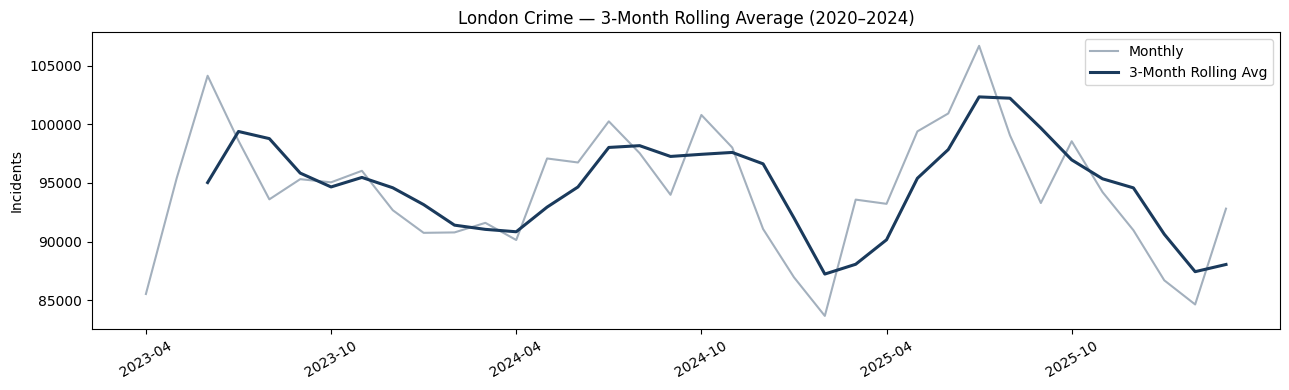

In [10]:
monthly = query("""
SELECT year_month, COUNT(*) AS incidents
FROM crime
GROUP BY year_month
ORDER BY year_month
""")
monthly['rolling_3m'] = monthly['incidents'].rolling(3).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.index, monthly['incidents'], color=BLUE, alpha=0.4, label='Monthly')
ax.plot(monthly.index, monthly['rolling_3m'], color=BLUE, linewidth=2.2, label='3-Month Rolling Avg')
ax.set_title('London Crime — 3-Month Rolling Average (2020–2024)')
ax.set_ylabel('Incidents')
ax.legend()
ax.set_xticks(monthly.index[::6])
ax.set_xticklabels(monthly['year_month'].iloc[::6], rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/chart_07_rolling_avg.png', bbox_inches='tight')
plt.show()

## Q9 — Outcome analysis: what % of crimes get resolved?

In [11]:
if 'last_outcome_category' in df.columns:
    display(query("""
    SELECT last_outcome_category,
           COUNT(*) AS incidents,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM crime
    WHERE last_outcome_category IS NOT NULL
    GROUP BY last_outcome_category
    ORDER BY incidents DESC
    LIMIT 10
    """))
else:
    print('outcome column not available in this dataset')

,last_outcome_category,incidents,pct
0,Investigation complete; no suspect identified,1680750,62.2
1,Unable to prosecute suspect,568313,21.0
2,Status update unavailable,144652,5.4
3,Under investigation,93995,3.5
4,Court result unavailable,80404,3.0
5,Local resolution,49613,1.8
6,Awaiting court outcome,47244,1.7
7,Action to be taken by another organisation,15489,0.6
8,Offender given a caution,8281,0.3
9,Offender given penalty notice,8155,0.3


## Q10 — Anti-social behaviour trend (often police-priority metric)

In [12]:
query("""
SELECT year,
       SUM(CASE WHEN crime_type = 'Anti-Social Behaviour' THEN 1 ELSE 0 END) AS asb_incidents,
       COUNT(*) AS total_incidents,
       ROUND(
           SUM(CASE WHEN crime_type = 'Anti-Social Behaviour' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
       ) AS asb_pct
FROM crime
GROUP BY year
ORDER BY year
""")

,year,asb_incidents,total_incidents,asb_pct
0,2023,177107,856305,20.7
1,2024,232405,1138656,20.4
2,2025,234967,1140416,20.6
3,2026,51264,264129,19.4
